In [1]:
pip install imbalanced-learn pandas numpy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'online_shoppers_intention_preprocessed.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,1,1,1,1,1,0,0
1,0,0.0,0,0.0,2,64.00,0.00,0.10,0.0,0.0,2,2,2,1,2,1,0,0
2,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,4,1,9,3,1,0,0
3,0,0.0,0,0.0,2,2.67,0.05,0.14,0.0,0.0,2,3,2,2,4,1,0,0
4,0,0.0,0,0.0,10,627.50,0.02,0.05,0.0,0.0,2,3,3,1,4,1,1,0


In [4]:
print(df['Revenue'].value_counts())

Revenue
0    10297
1     1908
Name: count, dtype: int64


In [5]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [6]:
smote = SMOTE(sampling_strategy='minority',random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

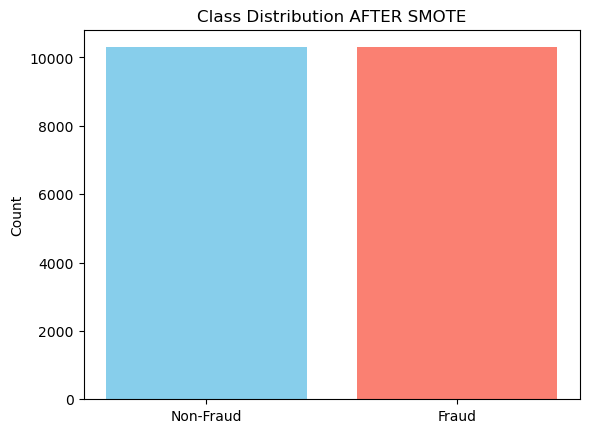

In [7]:
plt.bar(y_resampled.value_counts().index, y_resampled.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [8]:
print(df['Revenue'].value_counts())
print(y_resampled.value_counts())
print(X_resampled.value_counts())

Revenue
0    10297
1     1908
Name: count, dtype: int64
Revenue
0    10297
1    10297
Name: count, dtype: int64
Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  Browser  Region  TrafficType  VisitorType  Weekend
0               0.00                     0              0.0                     0               0.00                     0.18         0.18       0.00        0.0         6      2                 2        7       6            1            0          1
3               73.50                    3              171.0                   76              2208.79                  0.00         0.00       3.20        0.0         5      4                 1        7       2            1            1          1
                78.00                    0              0.0                     27              672.58                   0.01         0.04     

In [9]:
df_balanced = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['Revenue'])], axis=1)
print(df_balanced['Revenue'].value_counts())

Revenue
0    10297
1    10297
Name: count, dtype: int64


In [10]:
df_balanced.to_csv('online_shoppers_intention_preprocessed_smote.csv', index=False, encoding='utf-8')